# Detection of HIV inhibitors:
Exam of Advanced Computational Techniques for Big Imaging and Signal Data, june 2026

### The HIV epidemiology:
Human immunodeficiency virus (HIV) is a virus that attacks the body’s immune system. Acquired immunodeficiency syndrome (AIDS) occurs at the most advanced stage of infection.
- HIV can be prevented and treated with antiretroviral therapy (ART). Untreated HIV can progress to AIDS, often after many years and be potentially fatal.
- Since the beginning of the epidemic, **91.4 million** people have been infected with the HIV virus and about **44.1 million**  people have died from HIV-related causes.
Globally, 40.8 million people were living with HIV at the end of 2024.
- The WHO African Region remains most severely affected, with nearly 1 in every 30 adults (3.1%) living with HIV and accounting for more than two-thirds of the people living with HIV worldwide.


In [1]:
#from google.colab import drive
#drive.mount('/content/drive')

In [18]:
# REQUIREMENTS
%%capture
!pip install deepchem
!pip install torch-geometric
!pip install rdkit
!pip install py3Dmol

In [56]:
# IMPORTS

# RDKIT & DEEPCHEM
import rdkit
from rdkit import Chem
from rdkit.Chem import Draw, rdmolops
import deepchem as dc


# TORCH
import torch
import torch_geometric
from torch_geometric.data import Dataset
from torch_geometric.loader import DataLoader
from torch_geometric.datasets import MoleculeNet
from torch_geometric.utils import from_smiles
import torch.nn.functional as F # dropout
from torch.nn import Linear
from torch_geometric.nn import GCNConv, global_mean_pool, global_max_pool

# UTILITIES
import numpy as np
from numpy import random
from tqdm import tqdm
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

import torch
import json
from torch_geometric.loader import DataLoader
from sklearn.metrics import roc_auc_score

import numpy as np
from sklearn.model_selection import train_test_split
from torch_geometric.loader import DataLoader
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

In [57]:
SEED = 9 # 42, 0, 9
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

# Dataset: MoleculeNet — HIV

The dataset I used comes from PyTorch Geometric and it’s composed of 41.120 molecules, of which only 1443 are labeled as HIV Inhibitors.

Every molecule is a graph object with the following properties:
   

*   x = [n_atoms, 9]  (9 features per atom)
*   edge_index = [2, n_bonds]
*   edge_attr = [n_bonds, 3]  (bond type)
*   smiles string (es: CCC1=[O+][Cu-3]2([O+]=C(CC)C1))
*   label y = [1,1]



<br>

The dataset is highly unbalanced. We must take this into account when calculating accuracy. This is why the ROC-AUC it's a better metric here or F1 since we have that our model performs very good by simply putting 0 for every atom.


* **ROC AUC**: Measures the model's ability to distinguish between classes. Ranges from 0.5 (random) to 1.0 (perfect). Useful with imbalanced classes
because it's independent of the decision threshold.

* **F1 Score**: Harmonic mean of *precision* (how many positive predictions
are correct) and *recall* (how many actual positives are found).
Ranges from 0 to 1. Useful when you need few false positives *and* few false negatives.



Sources:

> Pytorch Dataset class: https://apxml.com/courses/getting-started-with-pytorch/chapter-5-efficient-data-handling/working-with-dataset

> MoleculeNet: https://pytorch-geometric.readthedocs.io/en/2.6.1/generated/torch_geometric.datasets.MoleculeNet.html




In [58]:
# IMPORT MY DATASET
dataset = MoleculeNet(root="data/HIV", name="HIV")
print('MoleculeNet HIV has been imported successfully...\n')

# CHECK IMBALANCE
non_inhibitors = 0
inhibitors = 0

for d in dataset:
  if d.y == 0:
    non_inhibitors += 1
  else:
    inhibitors +=1

print('Dataset lenght is:', len(dataset))
print('The non inhibitors are', non_inhibitors, 'approximately', round(non_inhibitors/len(dataset) * 100, 2), '%')
print('The inhibitors are', inhibitors, 'approximately', round(inhibitors/len(dataset) * 100,2), '%')

MoleculeNet HIV has been imported successfully...

Dataset lenght is: 41120
The non inhibitors are 39677 approximately 96.49 %
The inhibitors are 1443 approximately 3.51 %


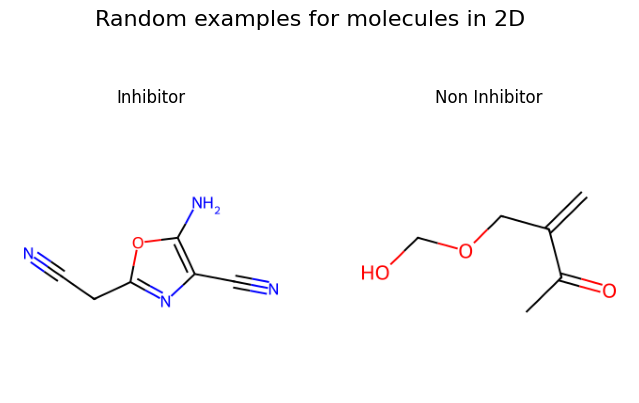

Inhibitor: N#CCc1nc(C#N)c(N)o1
Non Inhobitor: C=C(COCO)C(C)=O


In [59]:
# PLOT RANDOM MOLECULES
def pick_rand(dataset, label):
    dataset_shuff = dataset.shuffle()
    for d in dataset_shuff:
      if len(d.smiles) > 10 and len(d.smiles) < 20:
        if d.y == label:
            return d

# nota: se esce una molecola tipo CCOC(=O)C(C)=C(O)C(=O)OCC.[NaH], il
# significato è che Nah è una molecola miscelata con la mia molecola davanti al '.'

example_pos = pick_rand(dataset, 1)
example_neg = pick_rand(dataset, 0)

# PLOT THE CASUAL MOLECULES
fig, axs = plt.subplots(1,2, figsize=(8,5))

axs[0].imshow(Draw.MolToImage(Chem.MolFromSmiles(example_pos.smiles)))
axs[0].axis('off')
axs[0].set_title('Inhibitor')
axs[1].imshow(Draw.MolToImage(Chem.MolFromSmiles(example_neg.smiles)))
axs[1].axis('off')
axs[1].set_title('Non Inhibitor')
fig.suptitle('Random examples for molecules in 2D', fontsize=16)
plt.show()

print('Inhibitor:', example_pos.smiles)
print('Non Inhobitor:', example_neg.smiles)

# 1️⃣ Simple GCN with Smiles Enumeration
I wanted to perform data augmentation by using an Rdkit
https://www.knime.com/blog/4-techniques-handle-imbalanced-datasets

### Smiles Enumeration
I modify the dataset to have a probability of changing a smile configuration everytime that I access it. This works for every element


In [60]:
# SMILES ENUMERATION:
# Flips Smiles order with a fixed probability everytime I try to get an element of my dataset
class SmilesEnumDataset(Dataset):

    def __init__(self, data, prob = 0.5):
        self.probability = prob
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):

        # Pick an item and apply transf on the smiles to get a new data
        d = self.data.__getitem__(idx)

        if (random.random() < self.probability):
          mol = Chem.MolFromSmiles(d.smiles)
          smile_enum = Chem.MolToSmiles(mol, doRandom = True)
          smile_enum = from_smiles(smile_enum)
          smile_enum.y = d.y
          #print(smile_enum)
          return smile_enum

        else:
          return d

        sample = (torch.tensor(feature, dtype=torch.float32),
                  torch.tensor(label, dtype=torch.long))

        return sample


###  DATASET SPLIT
Here I prepare my dataset for use in the three different models I'll use the same split for the test in order to have comparable results.

In [61]:
labels = [int(d.y.item()) for d in dataset]

# TRAIN, TEST, VAL split
train_data, temp_data, train_labels, temp_labels = train_test_split(dataset, labels, test_size=0.20, stratify=labels, random_state=42)
val_data, test_data = train_test_split(temp_data, test_size=0.50, stratify=temp_labels, random_state=42)

print(f"Dimensione Train: {len(train_data)}")
print(f"Dimensione Validation: {len(val_data)}")
print(f"Dimensione Test: {len(test_data)}")

# RAW data is kept because I'll use it for method n.2
train_raw = train_data

# Perform SMILES ENUM
train_data = SmilesEnumDataset(train_data, prob=0.6)

Dimensione Train: 32896
Dimensione Validation: 4112
Dimensione Test: 4112


In [62]:
# BUILD THE DATALOADERS
# https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)

### Model definition

In [63]:
class SimpleGCN(torch.nn.Module):
    def __init__(self, num_node_features, hidden_channels):
        super().__init__()

        # CONV LAYERS
        self.conv1 = GCNConv(num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)

        # MLP
        self.lin = Linear(hidden_channels, 1)

    def forward(self, x, edge_index, batch):

        x = self.conv1(x, edge_index)
        x = x.relu()

        x = self.conv2(x, edge_index)
        x = x.relu()
        x = F.dropout(x, p=0.5, training=self.training)

        x = self.conv3(x, edge_index)
        x = global_mean_pool(x, batch)
        out = self.lin(x)
        return out

### TRAIN SimpleGCN

I perform the training and I select as the best model the one that gives me the best ROC AUC.


In [64]:
# CHECK GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Sto addestrando su: {device}")


# MODEL INIT
modello = SimpleGCN(9, 64)
modello = modello.to(device)

# OPTIMIZER AND CUSTOM LOSS WEIGHT (solves imbalance)
optimizer = torch.optim.Adam(modello.parameters(), lr=0.001)
peso_positivi = torch.tensor([27.0]).to(device)
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=peso_positivi)

Sto addestrando su: cuda


In [65]:
storia_train_loss = []
storia_val_loss = []
storia_val_auc = []
best_auc = 0.0

num_epoche = 50

for epoca in range(num_epoche):

    # TRAIN
    modello.train()
    loss_train_totale = 0

    for batch in train_loader:

        batch = batch.to(device)

        # dtypes check
        x_input = batch.x.float()
        edge_index_input = batch.edge_index.long()
        optimizer.zero_grad()

        # FORWARD, LOSS, BACKPROPA
        predizioni = modello(x_input, edge_index_input, batch.batch)
        loss = criterion(predizioni.squeeze(), batch.y.float().squeeze())
        loss.backward()
        optimizer.step()
        loss_train_totale += loss.item() #  all batches

    loss_media_train = loss_train_totale / len(train_loader)



    # VALIDATE
    modello.eval()
    loss_val_totale = 0
    corretti = 0
    totali = 0
    tutte_vere = []
    tutte_prob = []


    with torch.no_grad():
        for batch in val_loader:

            batch = batch.to(device)

            # dtypes check
            x_input = batch.x.float()
            edge_index_input = batch.edge_index.long()

            # PREDICT, LOSS
            predizioni = modello(x_input, edge_index_input, batch.batch)
            loss = criterion(predizioni.squeeze(), batch.y.float().squeeze())
            loss_val_totale += loss.item()

            # ACCURACY
            probabilita = torch.sigmoid(predizioni.squeeze())
            pred_labels = (probabilita > 0.5).float()
            corretti += (pred_labels == batch.y.float().squeeze()).sum().item()
            totali += len(batch.y)

            tutte_vere.extend(batch.y.float().squeeze().cpu().numpy()) # ROCAUC serve a salvare le vere labels
            tutte_prob.extend(probabilita.cpu().numpy())


    loss_media_val = loss_val_totale / len(val_loader)
    accuratezza_val = corretti / totali

    storia_train_loss.append(loss_media_train)
    storia_val_loss.append(loss_media_val)


    try:
        # Use tutte_vere and tutte_prob collected within the validation loop
        auc_corrente = roc_auc_score(tutte_vere, tutte_prob)
    except ValueError:
        auc_corrente = 0.5 # Nel caso rarissimo in cui in un batch ci sia solo una classe

    storia_val_auc.append(auc_corrente)

    # SALVA IL MODELLO CON MIGLIORE ROC-AUC
    if auc_corrente > best_auc and epoca > 5:
        best_auc = auc_corrente
        torch.save(modello.state_dict(), "simple_gcn_best.pth")
        print(f"nuovo best Val AUC: {best_auc:.4f} (checkpoint salvato)")


    if (epoca + 1) % 5 == 0 or epoca == 0:
        print(f'Epoca {epoca+1:03d} | Train Loss: {loss_media_train:.4f} | Val Loss: {loss_media_val:.4f} | Val AUC: {auc_corrente:.4f}')

    if (epoca + 1) % 5 == 0 or epoca == 0:
        print(f'Epoca {epoca+1:03d} | Train Loss: {loss_media_train:.4f} | Val Loss: {loss_media_val:.4f} | Val Acc: {accuratezza_val:.4f}')

print("\nAddestramento Completato! 🎉")

# CARICO MODELLO AUC MIGLIORE
modello.load_state_dict(torch.load("simple_gcn_best.pth"))
print(f"Ricaricato il best checkpoint — Val AUC = {best_auc:.4f}")

Epoca 001 | Train Loss: 1.3294 | Val Loss: 1.3069 | Val AUC: 0.6410
Epoca 001 | Train Loss: 1.3294 | Val Loss: 1.3069 | Val Acc: 0.7524
Epoca 005 | Train Loss: 1.2973 | Val Loss: 1.2769 | Val AUC: 0.6692
Epoca 005 | Train Loss: 1.2973 | Val Loss: 1.2769 | Val Acc: 0.7833
nuovo best Val AUC: 0.6651 (checkpoint salvato)
nuovo best Val AUC: 0.6750 (checkpoint salvato)
nuovo best Val AUC: 0.6803 (checkpoint salvato)
nuovo best Val AUC: 0.6885 (checkpoint salvato)
Epoca 010 | Train Loss: 1.2642 | Val Loss: 1.2270 | Val AUC: 0.6885
Epoca 010 | Train Loss: 1.2642 | Val Loss: 1.2270 | Val Acc: 0.6522
nuovo best Val AUC: 0.6973 (checkpoint salvato)
nuovo best Val AUC: 0.7011 (checkpoint salvato)
Epoca 015 | Train Loss: 1.2278 | Val Loss: 1.2275 | Val AUC: 0.6978
Epoca 015 | Train Loss: 1.2278 | Val Loss: 1.2275 | Val Acc: 0.6308
nuovo best Val AUC: 0.7043 (checkpoint salvato)
nuovo best Val AUC: 0.7085 (checkpoint salvato)
Epoca 020 | Train Loss: 1.2004 | Val Loss: 1.1836 | Val AUC: 0.7085
Epoc

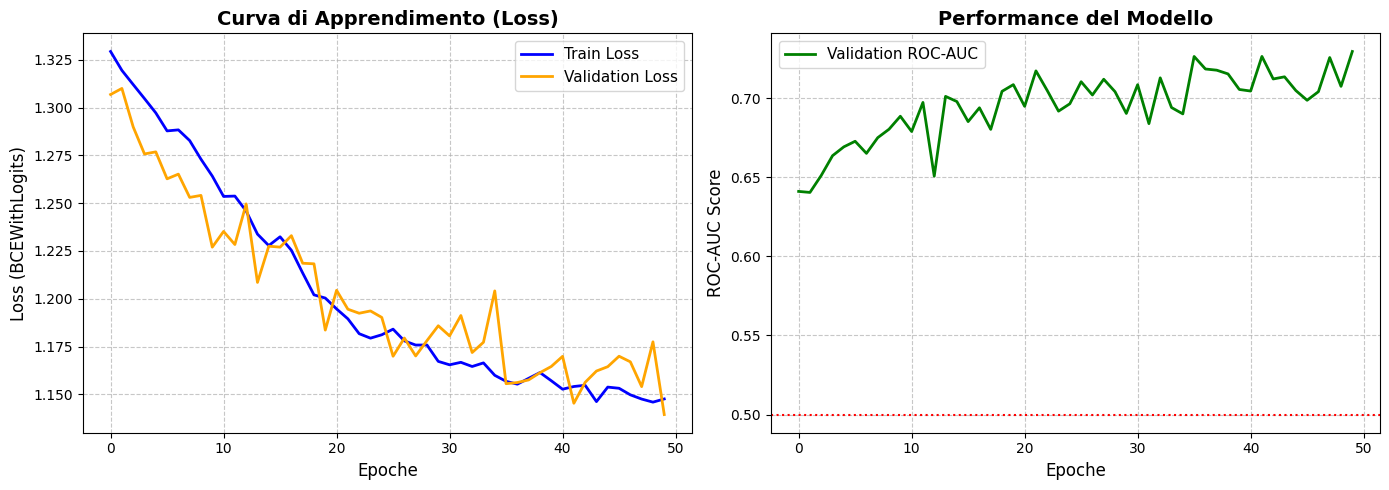

In [66]:
# PLOT LOSS & AUC
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# LOSS
ax1.plot(storia_train_loss, label='Train Loss', color='blue', linewidth=2)
ax1.plot(storia_val_loss, label='Validation Loss', color='orange', linewidth=2)
ax1.set_title('Curva di Apprendimento (Loss)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoche', fontsize=12)
ax1.set_ylabel('Loss (BCEWithLogits)', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.7)


# AUC
ax2.plot(storia_val_auc, label='Validation ROC-AUC', color='green', linewidth=2)
ax2.set_title('Performance del Modello', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoche', fontsize=12)
ax2.set_ylabel('ROC-AUC Score', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.axhline(y=0.5, color='red', linestyle=':', label='Casuale (0.5)')
plt.tight_layout()
plt.show()

=== MATRICE DI CONFUSIONE (normalizzata) ===
[[0.79133065 0.20866935]
 [0.47916667 0.52083333]]


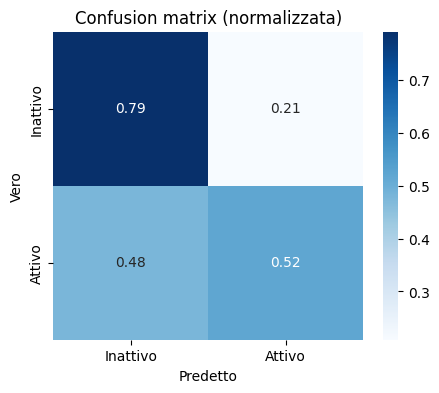


=== REPORT DETTAGLIATO ===
              precision    recall  f1-score   support

Inattivo (0)       0.98      0.79      0.88      3968
  Attivo (1)       0.08      0.52      0.14       144

    accuracy                           0.78      4112
   macro avg       0.53      0.66      0.51      4112
weighted avg       0.95      0.78      0.85      4112


=== LA METRICA REALE ===
ROC-AUC Score: 0.7098
PR-AUC Score : 0.1561   (piu' informativa col 3.5% di positivi)


In [67]:
from sklearn.metrics import average_precision_score

# EVALUATE ON TEST
modello.eval()
tutte_le_vere_label = []
tutte_le_probabilita = []

with torch.no_grad():
    for batch in test_loader:

        batch = batch.to(device)

        # dtypes
        x_input = batch.x.float()
        edge_index_input = batch.edge_index.long()

        #PREDICT
        predizioni = modello(x_input, edge_index_input, batch.batch)
        probabilita = torch.sigmoid(predizioni.view(-1))

        tutte_le_vere_label.extend(batch.y.view(-1).cpu().numpy()) #numpy solo cpu
        tutte_le_probabilita.extend(probabilita.cpu().numpy())

y_true = np.array(tutte_le_vere_label)
y_prob = np.array(tutte_le_probabilita)

#ARRAY CLASSIFICATION
y_pred = (y_prob > 0.5).astype(int)

print("=== MATRICE DI CONFUSIONE (normalizzata) ===")
# Formato:
# [Veri Negativi (0)  Falsi Positivi (falsi allarmi)]
# [Falsi Negativi     Veri Positivi (HIV trovati!)]
cm = confusion_matrix(y_true, y_pred, normalize='true')
print(cm)

import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=["Inattivo", "Attivo"], yticklabels=["Inattivo", "Attivo"])
plt.xlabel("Predetto"); plt.ylabel("Vero"); plt.title("Confusion matrix (normalizzata)")
plt.show()

print("\n=== REPORT DETTAGLIATO ===")
print(classification_report(y_true, y_pred, target_names=["Inattivo (0)", "Attivo (1)"]))

print("\n=== LA METRICA REALE ===")
roc_auc = roc_auc_score(y_true, y_prob)
print(f"ROC-AUC Score: {roc_auc:.4f}")

pr_auc = average_precision_score(y_true, y_prob)
print(f"PR-AUC Score : {pr_auc:.4f}   (piu' informativa col 3.5% di positivi)")

prob predetta: 0.220  (vero: attivo)
prob predetta: 0.251  (vero: attivo)
prob predetta: 0.261  (vero: attivo)


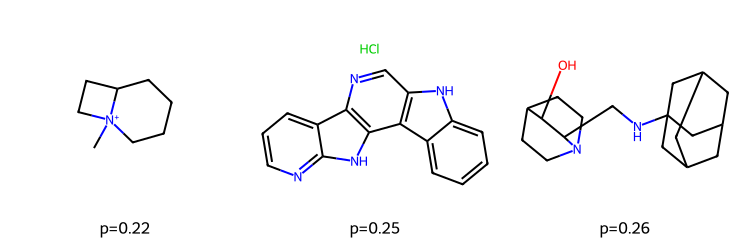

In [68]:
# 3 WORST DETECTED ONES
fn_idx = [i for i in range(len(y_true)) if y_true[i] == 1]
fn_idx = sorted(fn_idx, key=lambda i: y_prob[i])[:3]

for i in fn_idx:
    print(f"prob predetta: {y_prob[i]:.3f}  (vero: attivo)")

mols = [Chem.MolFromSmiles(test_data[i].smiles) for i in fn_idx]
Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(250, 250),
                     legends=[f"p={y_prob[i]:.2f}" for i in fn_idx])

## 2️⃣ Majority voting

I’ve decided to try this approach in order to solve the problem of imbalance. Also, this is done for SOTA models.

- Train dataset: split into 27 datasets with same Inhibitors and different non inhibitors each time to counterbalance disproportion effects
- Test dataset: same of SimpleGCN
- Configuration: 2 GCN layers +  global mean and global avg pool +  2 Linear Layers to speed up computations and maintain complexity

In [69]:
# Train_raw is the training dataset for the SimpleGCN network
dataset_0 = [d for d in train_raw if d.y == 0]
dataset_1 = [d for d in train_raw if d.y == 1]

random.seed(42)
random.shuffle(dataset_0)

blocco = len(dataset_0) // 27
dataset_0_splits = []
dataset_1_splits = []
for i in range(27):

  temp = dataset_0[i*blocco:(i+1)*blocco]
  dataset_0_splits.append(temp)
  dataset_1_splits.append(dataset_1)


In [70]:
# BUILD DATASETS
dataset_majority = {}

for i in range(27):
  labels = [int(d.y.item()) for d in dataset_0_splits[i]]

  train0_data, temp0_data, train0_labels, temp0_labels = train_test_split(dataset_0_splits[i], labels, test_size=0.20, random_state=42)
  val0_data, test0_data = train_test_split(temp0_data, test_size=0.50, random_state=42)


  # I'M GOING TO KEEP THE SAME DATA FOR LABEL 1: dataset_1_splits[0] is fine like that
  labels = [int(d.y.item()) for d in dataset_1_splits[0]]
  train1_data, temp1_data, train1_labels, temp1_labels = train_test_split(dataset_1_splits[0], labels, test_size=0.20, random_state=42)
  val1_data, test1_data = train_test_split(temp1_data, test_size=0.50, random_state=42)

  dataset_majority[f'lista{i}'] = {'train': train0_data + train1_data, 'test': test0_data + test1_data, 'val': val0_data+ val1_data}

len(dataset_majority['lista26']['train'])

1863

In [71]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Sto addestrando su: {device}")

Sto addestrando su: cuda


In [72]:
class MajorityGCN(torch.nn.Module):
    def __init__(self, num_node_features, hidden_channels):

        super().__init__()

        self.conv1 = GCNConv(num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)

        self.lin = Linear(2*hidden_channels, hidden_channels)
        self.lin2 = Linear(hidden_channels, 1)

    def forward(self, x, edge_index, batch):

        x = self.conv1(x, edge_index)
        x = x.relu()

        x = self.conv2(x, edge_index)
        x = x.relu()

        x_1 = global_mean_pool(x, batch)
        x_2 = global_max_pool(x, batch)
        x = torch.cat((x_1, x_2), dim=1)

        x = self.lin(x)
        x = x.relu()
        out = self.lin2(x)

        return out

In [74]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="torch_geometric")

In [75]:
# TRAIN ALL 27 MODELS

num_epoche = 50
tutte_le_storie = {}

for i in range(27):

    # MODEL, LOSS & OPTIMIZER DEF
    modello = MajorityGCN(9, 64)
    modello = modello.to(device)

    optimizer = torch.optim.Adam(modello.parameters(), lr=0.001)
    criterion = torch.nn.BCEWithLogitsLoss()

    # DATALOADER
    train_loader = DataLoader(dataset_majority[f'lista{i}']['train'], batch_size=64, shuffle=True)
    test_loader = DataLoader(dataset_majority[f'lista{i}']['test'], batch_size=64, shuffle=False)
    val_loader = DataLoader(dataset_majority[f'lista{i}']['val'], batch_size=64, shuffle=False)

    storia_train_loss = []
    storia_val_loss = []
    storia_val_auc = []

    # TRAIN
    for epoca in range(num_epoche):

        modello.train()
        loss_train_totale = 0

        for batch in train_loader:
            batch = batch.to(device)

            # CONTROLLO FORMATTAZIONE
            x_input = batch.x.float()
            edge_index_input = batch.edge_index.long()

            # TRAINING
            optimizer.zero_grad()
            predizioni = modello(x_input, edge_index_input, batch.batch)
            loss = criterion(predizioni.squeeze(), batch.y.float().squeeze())
            loss.backward()
            optimizer.step()
            loss_train_totale += loss.item()

        loss_media_train = loss_train_totale / len(train_loader)


        # VALIDATION
        modello.eval()
        loss_val_totale = 0
        corretti = 0
        totali = 0
        tutte_vere = []
        tutte_prob = []

        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)

                # dtypes
                x_input = batch.x.float()
                edge_index_input = batch.edge_index.long()

                predizioni = modello(x_input, edge_index_input, batch.batch)
                loss = criterion(predizioni.squeeze(), batch.y.float().squeeze())
                loss_val_totale += loss.item()

                probabilita = torch.sigmoid(predizioni.squeeze())
                pred_labels = (probabilita > 0.5).float()

                corretti += (pred_labels == batch.y.float().squeeze()).sum().item()
                totali += len(batch.y)

                tutte_vere.extend(batch.y.float().squeeze().cpu().numpy())
                tutte_prob.extend(probabilita.cpu().numpy())

        loss_media_val = loss_val_totale / len(val_loader)
        accuratezza_val = corretti / totali

        storia_train_loss.append(loss_media_train)
        storia_val_loss.append(loss_media_val)

        try:
            auc_corrente = roc_auc_score(tutte_vere, tutte_prob)
        except ValueError:
            auc_corrente = 0.5

        storia_val_auc.append(auc_corrente)

        if (epoca + 1) % 5 == 0 or epoca == 0:
            print(f'Epoca {epoca+1:03d} | Train Loss: {loss_media_train:.4f} | Val Loss: {loss_media_val:.4f} | Val AUC: {auc_corrente:.4f} | Val Acc: {accuratezza_val:.4f}')

    print(f"✅ Addestramento Modello {i} Completato!")

    nome_file_modello = f"modello_pesi_lista_{i}.pth"
    torch.save(modello.state_dict(), nome_file_modello)
    print(f"💾 Pesi salvati in: {nome_file_modello}")

    tutte_le_storie[f"lista{i}"] = {
        "train_loss": storia_train_loss,
        "val_loss": storia_val_loss,
        "val_auc": storia_val_auc
    }




with open("storia_tutti_i_modelli.json", "w") as f:
    json.dump(tutte_le_storie, f, indent=4)

print("\n🎉 TUTTO FATTO! 27 modelli addestrati e salvati con successo!")

Epoca 001 | Train Loss: 0.6900 | Val Loss: 0.6911 | Val AUC: 0.6002 | Val Acc: 0.5733
Epoca 005 | Train Loss: 0.6696 | Val Loss: 0.6724 | Val AUC: 0.6386 | Val Acc: 0.5948
Epoca 010 | Train Loss: 0.6471 | Val Loss: 0.6326 | Val AUC: 0.6684 | Val Acc: 0.5733
Epoca 015 | Train Loss: 0.6366 | Val Loss: 0.6281 | Val AUC: 0.6819 | Val Acc: 0.5948
Epoca 020 | Train Loss: 0.6325 | Val Loss: 0.6212 | Val AUC: 0.6931 | Val Acc: 0.6034
Epoca 025 | Train Loss: 0.6217 | Val Loss: 0.6358 | Val AUC: 0.7057 | Val Acc: 0.6509
Epoca 030 | Train Loss: 0.6065 | Val Loss: 0.6156 | Val AUC: 0.7127 | Val Acc: 0.6250
Epoca 035 | Train Loss: 0.6053 | Val Loss: 0.6102 | Val AUC: 0.7183 | Val Acc: 0.6422
Epoca 040 | Train Loss: 0.6081 | Val Loss: 0.6073 | Val AUC: 0.7211 | Val Acc: 0.6509
Epoca 045 | Train Loss: 0.5894 | Val Loss: 0.6088 | Val AUC: 0.7352 | Val Acc: 0.6724
Epoca 050 | Train Loss: 0.5812 | Val Loss: 0.6021 | Val AUC: 0.7338 | Val Acc: 0.6552
✅ Addestramento Modello 0 Completato!
💾 Pesi salvati i

# Majority Voting (Ensemble dei 27 modelli)

1. Ricostruisco lo **stesso** test set tenuto da parte in fase di training (blocchi classe 0 disgiunti + classe 1 condivisa).
2. Ricarico i 27 `MajorityGCN` dai file `modello_pesi_lista_{i}.pth`.
3. Ogni modello produce una probabilita per ogni molecola.
4. Aggrego con **hard voting** (voto di maggioranza, >=14/27) e **soft voting** (media delle probabilita).

In [76]:
# TEST SET
NUM_MODELLI = 27
test_comune = test_data
print(len(test_comune))

4112


In [77]:
# LOAD MODELS
modelli = []
for i in range(NUM_MODELLI):
    m = MajorityGCN(9, 64).to(device)
    m.load_state_dict(torch.load(f"modello_pesi_lista_{i}.pth", map_location=device))
    m.eval()
    modelli.append(m)

print(f"Caricati {len(modelli)} modelli.")


Caricati 27 modelli.


In [78]:
# EVAL ON TEST
test_loader = DataLoader(test_comune, batch_size=64, shuffle=False)

y_true = []
prob_per_modello = [[] for _ in range(NUM_MODELLI)]

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        x_input = batch.x.float()
        edge_index_input = batch.edge_index.long()

        y_true.extend(batch.y.float().view(-1).cpu().numpy())

        for j, m in enumerate(modelli):
            out = m(x_input, edge_index_input, batch.batch)
            prob = torch.sigmoid(out.view(-1))          # view(-1) e' robusto anche con batch da 1
            prob_per_modello[j].extend(prob.cpu().numpy())

y_true = np.array(y_true)
prob_matrix = np.array(prob_per_modello)   # forma: [27, N_molecole]
print("Matrice probabilita:", prob_matrix.shape)


Matrice probabilita: (27, 4112)


================ HARD VOTING (>=14/27) ================
[[2744 1224]
 [  63   81]]
              precision    recall  f1-score   support

Inattivo (0)       0.98      0.69      0.81      3968
  Attivo (1)       0.06      0.56      0.11       144

    accuracy                           0.69      4112
   macro avg       0.52      0.63      0.46      4112
weighted avg       0.95      0.69      0.79      4112

================ SOFT VOTING (media prob) =============
[[2736 1232]
 [  62   82]]
              precision    recall  f1-score   support

Inattivo (0)       0.98      0.69      0.81      3968
  Attivo (1)       0.06      0.57      0.11       144

    accuracy                           0.69      4112
   macro avg       0.52      0.63      0.46      4112
weighted avg       0.95      0.69      0.78      4112


ROC-AUC (soft, prob media): 0.6736
ROC-AUC (hard, frazione voti): 0.6760
PR-AUC (soft voting): 0.1133   (baseline casuale = 0.035)


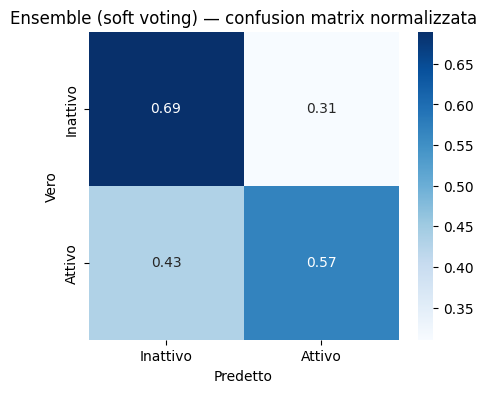

In [80]:
# MAJ VOTING

# HARD VOTING
voti = (prob_matrix > 0.5).astype(int)
somma_voti = voti.sum(axis=0)
y_pred_hard = (somma_voti >= (14)).astype(int)

# SOFT VOTING
prob_media = prob_matrix.mean(axis=0)
y_pred_soft = (prob_media > 0.5).astype(int)

print("================ HARD VOTING (>=14/27) ================")
print(confusion_matrix(y_true, y_pred_hard))
print(classification_report(y_true, y_pred_hard,
      target_names=["Inattivo (0)", "Attivo (1)"]))

print("================ SOFT VOTING (media prob) =============")
print(confusion_matrix(y_true, y_pred_soft))
print(classification_report(y_true, y_pred_soft,
      target_names=["Inattivo (0)", "Attivo (1)"]))

# ROC-AUC: si usano le probabilita (la media e' la scelta naturale per l'ensemble)
auc_soft = roc_auc_score(y_true, prob_media)
auc_hard = roc_auc_score(y_true, somma_voti / NUM_MODELLI)  # frazione di voti come "score"
print(f"\nROC-AUC (soft, prob media): {auc_soft:.4f}")
print(f"ROC-AUC (hard, frazione voti): {auc_hard:.4f}")


from sklearn.metrics import average_precision_score
import matplotlib.pyplot as plt, seaborn as sns

pr_auc_soft = average_precision_score(y_true, prob_media)
print(f"PR-AUC (soft voting): {pr_auc_soft:.4f}   (baseline casuale = 0.035)")

cm = confusion_matrix(y_true, y_pred_soft, normalize='true')
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=["Inattivo", "Attivo"], yticklabels=["Inattivo", "Attivo"])
plt.xlabel("Predetto"); plt.ylabel("Vero")
plt.title("Ensemble (soft voting) — confusion matrix normalizzata")
plt.show()

#Transfer Learning

Freezing a huge net


In [81]:
%%capture
!pip install transformers

In [82]:
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModel

# ChemBERTa pre-addestrato su SMILES (PubChem). Si puo' sostituire con altri,
# es. "seyonec/ChemBERTa-zinc-base-v1".
MODEL_NAME = "DeepChem/ChemBERTa-77M-MLM"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class ChemBERTaClassifier(nn.Module):
    def __init__(self, model_name=MODEL_NAME, freeze_backbone=True):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name)
        hidden = self.backbone.config.hidden_size

        # Congelo il backbone: alleno solo la testa (veloce e stabile).
        # Metti freeze_backbone=False per il fine-tuning completo.
        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False

        self.head = nn.Sequential(
            nn.Linear(hidden, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 1)          # 1 logit per classificazione binaria
        )

    def forward(self, input_ids, attention_mask):
        out = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]   # rappresentazione del token [CLS]
        return self.head(cls)

print("Tokenizer e modello pronti.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/631 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.27k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/6.96k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/8.26k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/420 [00:00<?, ?B/s]

Tokenizer e modello pronti.


In [83]:
from torch.utils.data import Dataset, DataLoader as TorchDataLoader

class SmilesDataset(Dataset):
    """Tokenizza gli SMILES al volo per ChemBERTa."""
    def __init__(self, smiles_list, labels, tokenizer, max_len=128):
        self.smiles = smiles_list
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.smiles)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.smiles[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt",
        )
        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "label": torch.tensor(self.labels[idx], dtype=torch.float32),
        }

In [84]:
from sklearn.model_selection import train_test_split

# Estraggo SMILES + label dal dataset MoleculeNet (NON tocco la variabile dataset).
smiles_all = [d.smiles for d in dataset]
y_all = [int(d.y.item()) for d in dataset]

# ChemBERTa riusa lo STESSO split canonico -> test identico per costruzione
sm_train, y_train = [d.smiles for d in train_raw], [int(d.y.item()) for d in train_raw]
sm_val,   y_val   = [d.smiles for d in val_data],  [int(d.y.item()) for d in val_data]
sm_test,  y_test  = [d.smiles for d in test_data], [int(d.y.item()) for d in test_data]

train_ds = SmilesDataset(sm_train, y_train, tokenizer)
val_ds   = SmilesDataset(sm_val,   y_val,   tokenizer)
test_ds  = SmilesDataset(sm_test,  y_test,  tokenizer)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

Train: 32896 | Val: 4112 | Test: 4112


In [85]:
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Sto addestrando su: {device}")

BATCH_SIZE = 64
train_loader = TorchDataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = TorchDataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = TorchDataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

modello_bert = ChemBERTaClassifier(freeze_backbone=True).to(device)

# Alleno solo i parametri NON congelati (la testa)
parametri = filter(lambda p: p.requires_grad, modello_bert.parameters())
optimizer = optim.Adam(parametri, lr=1e-3)

# Loss pesata per lo sbilanciamento (n_negativi / n_positivi sul train)
n_pos = sum(y_train)
n_neg = len(y_train) - n_pos
peso_positivi = torch.tensor([n_neg / n_pos]).to(device)
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=peso_positivi)
print(f"pos_weight = {peso_positivi.item():.2f}")

Sto addestrando su: cuda


pytorch_model.bin:   0%|          | 0.00/13.7M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/53 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: DeepChem/ChemBERTa-77M-MLM
Key                       | Status     | 
--------------------------+------------+-
lm_head.decoder.bias      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.decoder.weight    | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


pos_weight = 27.51


In [87]:
import numpy as np
from sklearn.metrics import roc_auc_score

num_epoche = 20
best_auc = 0.0
for epoca in range(num_epoche):
    # TRAINING
    modello_bert.train()
    loss_totale = 0
    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        y_true = batch["label"].to(device)

        optimizer.zero_grad()
        logits = modello_bert(input_ids, attention_mask).squeeze(-1)
        loss = criterion(logits, y_true)
        loss.backward()
        optimizer.step()
        loss_totale += loss.item()
    loss_media = loss_totale / len(train_loader)

    #VALIDATION
    modello_bert.eval()
    tutte_vere, tutte_prob = [], []
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            logits = modello_bert(input_ids, attention_mask).squeeze(-1)
            prob = torch.sigmoid(logits)
            tutte_vere.extend(batch["label"].numpy())
            tutte_prob.extend(prob.cpu().numpy())

    try:
        auc_val = roc_auc_score(tutte_vere, tutte_prob)
    except ValueError:
        auc_val = 0.5
    if auc_val > best_auc:
        best_auc = auc_val
        torch.save(modello_bert.state_dict(), "chemberta_best.pth")
    print(f"Epoca {epoca+1:02d} | Train Loss: {loss_media:.4f} | Val ROC-AUC: {auc_val:.4f}")

print("Fine training ChemBERTa!")

modello_bert.load_state_dict(torch.load("chemberta_best.pth"))

Epoca 01 | Train Loss: 1.1297 | Val ROC-AUC: 0.7137
Epoca 02 | Train Loss: 1.1157 | Val ROC-AUC: 0.7350
Epoca 03 | Train Loss: 1.0971 | Val ROC-AUC: 0.7356
Epoca 04 | Train Loss: 1.0768 | Val ROC-AUC: 0.7302
Epoca 05 | Train Loss: 1.0768 | Val ROC-AUC: 0.7289
Epoca 06 | Train Loss: 1.0559 | Val ROC-AUC: 0.7421
Epoca 07 | Train Loss: 1.0536 | Val ROC-AUC: 0.7469
Epoca 08 | Train Loss: 1.0352 | Val ROC-AUC: 0.7352
Epoca 09 | Train Loss: 1.0199 | Val ROC-AUC: 0.7467
Epoca 10 | Train Loss: 1.0131 | Val ROC-AUC: 0.7524
Epoca 11 | Train Loss: 1.0008 | Val ROC-AUC: 0.7365
Epoca 12 | Train Loss: 0.9988 | Val ROC-AUC: 0.7521
Epoca 13 | Train Loss: 0.9983 | Val ROC-AUC: 0.7577
Epoca 14 | Train Loss: 0.9803 | Val ROC-AUC: 0.7428
Epoca 15 | Train Loss: 0.9846 | Val ROC-AUC: 0.7660
Epoca 16 | Train Loss: 0.9763 | Val ROC-AUC: 0.7471
Epoca 17 | Train Loss: 0.9510 | Val ROC-AUC: 0.7584
Epoca 18 | Train Loss: 0.9560 | Val ROC-AUC: 0.7625
Epoca 19 | Train Loss: 0.9606 | Val ROC-AUC: 0.7586
Epoca 20 | T

<All keys matched successfully>

ROC-AUC : 0.7516
PR-AUC  : 0.2625   (baseline casuale = 0.035)

               precision    recall  f1-score   support

Inattivo (0)       0.98      0.78      0.87      3968
  Attivo (1)       0.09      0.60      0.16       144

    accuracy                           0.77      4112
   macro avg       0.54      0.69      0.51      4112
weighted avg       0.95      0.77      0.84      4112



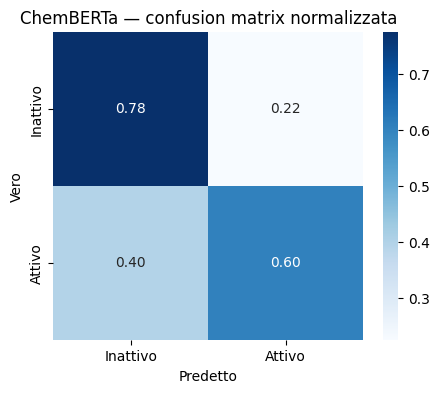

=== MATRICE DI CONFUSIONE ===
[[3077  891]
 [  57   87]]

=== REPORT DETTAGLIATO ===
              precision    recall  f1-score   support

Inattivo (0)       0.98      0.78      0.87      3968
  Attivo (1)       0.09      0.60      0.16       144

    accuracy                           0.77      4112
   macro avg       0.54      0.69      0.51      4112
weighted avg       0.95      0.77      0.84      4112


ROC-AUC Score: 0.7516


In [88]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

#TEST FINALE
modello_bert.eval()
y_vere, y_prob = [], []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        logits = modello_bert(input_ids, attention_mask).squeeze(-1)
        prob = torch.sigmoid(logits)
        y_vere.extend(batch["label"].numpy())
        y_prob.extend(prob.cpu().numpy())

y_vere = np.array(y_vere)
y_prob = np.array(y_prob)

from sklearn.metrics import average_precision_score
import matplotlib.pyplot as plt, seaborn as sns

y_pred = (y_prob > 0.5).astype(int)

print(f"ROC-AUC : {roc_auc_score(y_vere, y_prob):.4f}")
print(f"PR-AUC  : {average_precision_score(y_vere, y_prob):.4f}   (baseline casuale = 0.035)")
print("\n", classification_report(y_vere, y_pred, target_names=["Inattivo (0)", "Attivo (1)"]))

cm = confusion_matrix(y_vere, y_pred, normalize='true')
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=["Inattivo", "Attivo"], yticklabels=["Inattivo", "Attivo"])
plt.xlabel("Predetto"); plt.ylabel("Vero"); plt.title("ChemBERTa — confusion matrix normalizzata")
plt.show()


print("=== MATRICE DI CONFUSIONE ===")
print(confusion_matrix(y_vere, y_pred))
print("\n=== REPORT DETTAGLIATO ===")
print(classification_report(y_vere, y_pred, target_names=["Inattivo (0)", "Attivo (1)"]))
print(f"\nROC-AUC Score: {roc_auc_score(y_vere, y_prob):.4f}")

In [89]:
torch.save(modello_bert.state_dict(), "chemberta.pth")

=== SINGOLI (riferimento) ===
SimpleGCN    ROC-AUC 0.7098 | PR-AUC 0.1561
Ensemble-27  ROC-AUC 0.6736 | PR-AUC 0.1133
ChemBERTa    ROC-AUC 0.7516 | PR-AUC 0.2625

=== META-ENSEMBLE (soft voting) ===
ROC-AUC 0.7666 | PR-AUC 0.2065
              precision    recall  f1-score   support

Inattivo (0)       0.98      0.81      0.89      3968
  Attivo (1)       0.10      0.60      0.17       144

    accuracy                           0.80      4112
   macro avg       0.54      0.70      0.53      4112
weighted avg       0.95      0.80      0.86      4112



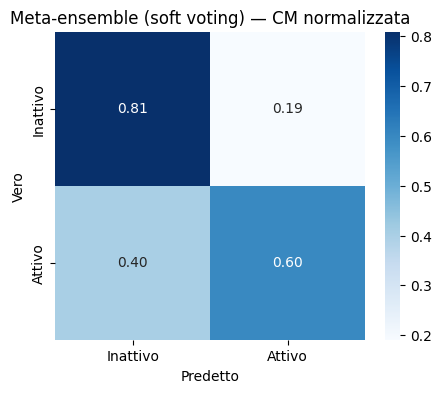

In [90]:
# ============================================================
# META-ENSEMBLE: voting tra SimpleGCN, Ensemble-27 e ChemBERTa
# Tutti e tre sullo STESSO test_data (shuffle=False) -> gia' allineati
# ============================================================
import numpy as np, torch
import matplotlib.pyplot as plt, seaborn as sns
from torch_geometric.loader import DataLoader as PyGLoader
from torch.utils.data import DataLoader as TorchLoader
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             confusion_matrix, classification_report)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
y_ref = np.array([int(d.y.item()) for d in test_data])   # ordine di riferimento

# --- 1) SimpleGCN: ricarico i pesi salvati ---
m_gcn = SimpleGCN(9, 64).to(device)
m_gcn.load_state_dict(torch.load("simple_gcn_best.pth", map_location=device))  # <-- usa il nome con cui l'hai salvato
m_gcn.eval()
prob_gcn = []
with torch.no_grad():
    for b in PyGLoader(test_data, batch_size=64, shuffle=False):
        b = b.to(device)
        prob_gcn.extend(torch.sigmoid(m_gcn(b.x.float(), b.edge_index.long(), b.batch).view(-1)).cpu().numpy())
prob_gcn = np.array(prob_gcn)

# --- 2) Ensemble-27: media dei 27 MajorityGCN (lista 'modelli' gia' caricata) ---
acc = [[] for _ in range(NUM_MODELLI)]
with torch.no_grad():
    for b in PyGLoader(test_data, batch_size=64, shuffle=False):
        b = b.to(device)
        for j, m in enumerate(modelli):
            acc[j].extend(torch.sigmoid(m(b.x.float(), b.edge_index.long(), b.batch).view(-1)).cpu().numpy())
prob_ens = np.array(acc).mean(axis=0)

# --- 3) ChemBERTa: modello in memoria (modello_bert) ---
prob_bert = []
modello_bert.eval()
with torch.no_grad():
    for b in TorchLoader(SmilesDataset(sm_test, y_test, tokenizer), batch_size=64, shuffle=False):
        out = modello_bert(b["input_ids"].to(device), b["attention_mask"].to(device)).squeeze(-1)
        prob_bert.extend(torch.sigmoid(out).cpu().numpy())
prob_bert = np.array(prob_bert)

# --- 4) COMBINO ---
prob_soft = (prob_gcn + prob_ens + prob_bert) / 3                 # soft voting (media prob)
voti = (np.vstack([prob_gcn, prob_ens, prob_bert]) > 0.5).astype(int)
pred_hard = (voti.sum(axis=0) >= 2).astype(int)                  # hard voting (>=2/3)
pred_soft = (prob_soft > 0.5).astype(int)

print("=== SINGOLI (riferimento) ===")
for nome, p in [("SimpleGCN", prob_gcn), ("Ensemble-27", prob_ens), ("ChemBERTa", prob_bert)]:
    print(f"{nome:12s} ROC-AUC {roc_auc_score(y_ref,p):.4f} | PR-AUC {average_precision_score(y_ref,p):.4f}")

print("\n=== META-ENSEMBLE (soft voting) ===")
print(f"ROC-AUC {roc_auc_score(y_ref, prob_soft):.4f} | PR-AUC {average_precision_score(y_ref, prob_soft):.4f}")
print(classification_report(y_ref, pred_soft, target_names=["Inattivo (0)", "Attivo (1)"]))

cm = confusion_matrix(y_ref, pred_soft, normalize='true')
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=["Inattivo","Attivo"], yticklabels=["Inattivo","Attivo"])
plt.xlabel("Predetto"); plt.ylabel("Vero"); plt.title("Meta-ensemble (soft voting) — CM normalizzata")
plt.show()